## Imports

In [1]:
from modules import *

In [2]:
import sys
from pathlib import Path

root = Path.cwd().parent          # assignment/
sys.path.insert(0, str(root))

from data_utils import *          # data_utils.py in the root

## Load data & hyperparams

In [3]:
data = load_memmap_dataset('/Users/anubhav/Desktop/Courses/Fall 26/Assignments/NLP/assignment_2/data/tinystories_valid.bin', '/Users/anubhav/Desktop/Courses/Fall 26/Assignments/NLP/assignment_2/data/tinystories_valid.meta')
vocab, merges = load_vocab("/Users/anubhav/Desktop/Courses/Fall 26/Assignments/NLP/assignment_2/data/tinystories_vocab_merges.pt")

In [4]:
params = {
    "VOCAB_SIZE": 10_000,
    "CONTEXT_LENGTH": 128,
    "D_MODEL": 128,
    "NUM_LAYERS": 4,
    "NUM_HEADS": 4,
    "D_FF": 384,
    "ROPE_THETA": 10000.0,
    "DEVICE": "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu",
    
    "BATCH_SIZE": 32,
    "MAX_LR": 1e-3,
    "MIN_LR": 1e-4,
    "WARMUP_ITERS": 100,
    "TOTAL_STEPS": 500,
    "WEIGHT_DECAY": 0.01,
    "MAX_GRAD_NORM": 1.0
}

for k,v in params.items():
    print(f"{k}: {v}")

VOCAB_SIZE: 10000
CONTEXT_LENGTH: 128
D_MODEL: 128
NUM_LAYERS: 4
NUM_HEADS: 4
D_FF: 384
ROPE_THETA: 10000.0
DEVICE: mps
BATCH_SIZE: 32
MAX_LR: 0.001
MIN_LR: 0.0001
WARMUP_ITERS: 100
TOTAL_STEPS: 500
WEIGHT_DECAY: 0.01
MAX_GRAD_NORM: 1.0


## Util for generating output

In [5]:
@torch.no_grad()
def generate_output(model, prompt_ids, max_new_tokens=60):
    model.eval()
    ids = torch.tensor([prompt_ids], device=params['DEVICE'])
    for _ in range(max_new_tokens):
        logits = model(ids[:, -params['CONTEXT_LENGTH']:])[:, -1, :]
        next_id = logits.argmax(dim=-1, keepdim=True)    # greedy
        ids = torch.cat([ids, next_id], dim=1)
    return ids[0].tolist()

prompt = data[:10].tolist()
print(f"PROMPT:\n")
print(decode(prompt, vocab))

PROMPT:

u don't have to be scared of the loud


In [6]:
MyGPT = TransformerLM(
    vocab_size=params["VOCAB_SIZE"],
    context_length=params["CONTEXT_LENGTH"],
    d_model=params["D_MODEL"],
    num_layers=params["NUM_LAYERS"],
    num_heads=params["NUM_HEADS"],
    d_ff=params["D_FF"],
    rope_theta=params["ROPE_THETA"],
    device=params["DEVICE"]
)

MyOptimizer = AdamW(params=MyGPT.parameters())

In [7]:
print(f"Initial decoding result:\n")
print(decode(generate_output(MyGPT, prompt), vocab))

Initial decoding result:

u don't have to be scared of the loud liqu nibb� novel Be winding quitecovered�?” strings backpackTina inter drink ends activity JamieHa scaring Jolly hundred appear keyhole bunny since connected rest fleasractedFind chopping pearsitely glove FreddieSince bankarac attach cutting Grumpy lotion True gl body spending deter afterwardsSince bank Since gigg folds Open disturbing Quacky dreaming choppingout


## Training Model

In [8]:
losses = []
MyGPT.train()
for step in range(params['TOTAL_STEPS']):
    # 1. set the scheduled lr
    lr = get_lr_cosine_schedule(
        it=step,
        max_learning_rate=params['MAX_LR'],
        min_learning_rate=params['MIN_LR'],
        warmup_iters=params['WARMUP_ITERS'],
        cosine_cycle_iters=params['TOTAL_STEPS']
    )
    for group in MyOptimizer.param_groups:
        group["lr"] = lr

    # 2. sample a batch
    x, y = get_batch(data, params['BATCH_SIZE'], params['CONTEXT_LENGTH'], params['DEVICE'])

    # 3. forward, loss, backward
    logits = MyGPT(x)                      # (batch, seq, vocab)
    loss = cross_entropy(inputs=logits, targets=y)        # your version handles the extra dim
    MyOptimizer.zero_grad()
    loss.backward()

    # 4. clip, then step
    gradient_clipping(parameters=MyGPT.parameters(), max_l2_norm=params['MAX_GRAD_NORM'])
    MyOptimizer.step()

    losses.append(loss.item())
    if step % 50 == 0:
        print(f"step {step:5d} | loss {loss.item():.4f} | lr {lr:.2e}")

step     0 | loss 9.2274 | lr 0.00e+00
step    50 | loss 7.1648 | lr 5.00e-04
step   100 | loss 5.2723 | lr 1.00e-03
step   150 | loss 4.2641 | lr 9.66e-04
step   200 | loss 3.8815 | lr 8.68e-04
step   250 | loss 3.5576 | lr 7.22e-04
step   300 | loss 3.4473 | lr 5.50e-04
step   350 | loss 3.4896 | lr 3.78e-04
step   400 | loss 3.4505 | lr 2.32e-04
step   450 | loss 3.2933 | lr 1.34e-04


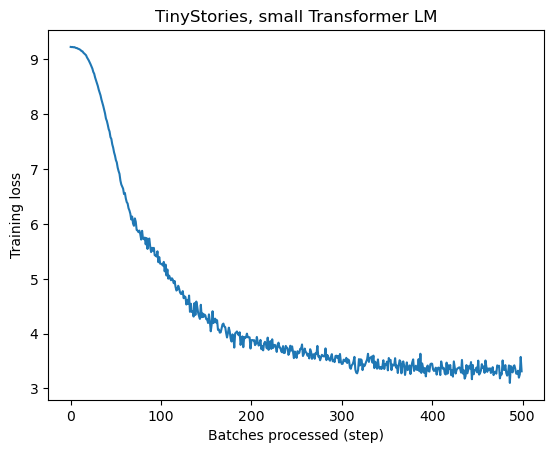

In [9]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Batches processed (step)")
plt.ylabel("Training loss")
plt.title("TinyStories, small Transformer LM")
plt.show()

In [10]:
print(f"After training LM decoding result:\n")
print(decode(generate_output(MyGPT, prompt), vocab))

After training LM decoding result:

u don't have to be scared of the loud.

Once upon a time, there was a little girl named Lily. She loved to play with his friends. One day, he saw a big, big tree. She was very happy. She wanted to play with the ball.
The little girl was very happy. She wanted to play


In [11]:
print(f"The actual text:\n")
print(decode(data[:50], vocab))

The actual text:

u don't have to be scared of the loud dog, I'll protect you". The mole felt so safe with the little girl. She was very kind and the mole soon came to trust her. He leaned against her and she kept him safe.


In [12]:
torch.save(MyGPT.state_dict(), 'model_weights.pth')

In [14]:
MyGPT.state_dict().keys()

odict_keys(['token_embedding.E', 'blocks.0.rmsnorm1.g', 'blocks.0.multihead.Query.W', 'blocks.0.multihead.Key.W', 'blocks.0.multihead.Value.W', 'blocks.0.multihead.Output.W', 'blocks.0.rmsnorm2.g', 'blocks.0.ffn.W1.W', 'blocks.0.ffn.W2.W', 'blocks.0.ffn.W3.W', 'blocks.1.rmsnorm1.g', 'blocks.1.multihead.Query.W', 'blocks.1.multihead.Key.W', 'blocks.1.multihead.Value.W', 'blocks.1.multihead.Output.W', 'blocks.1.rmsnorm2.g', 'blocks.1.ffn.W1.W', 'blocks.1.ffn.W2.W', 'blocks.1.ffn.W3.W', 'blocks.2.rmsnorm1.g', 'blocks.2.multihead.Query.W', 'blocks.2.multihead.Key.W', 'blocks.2.multihead.Value.W', 'blocks.2.multihead.Output.W', 'blocks.2.rmsnorm2.g', 'blocks.2.ffn.W1.W', 'blocks.2.ffn.W2.W', 'blocks.2.ffn.W3.W', 'blocks.3.rmsnorm1.g', 'blocks.3.multihead.Query.W', 'blocks.3.multihead.Key.W', 'blocks.3.multihead.Value.W', 'blocks.3.multihead.Output.W', 'blocks.3.rmsnorm2.g', 'blocks.3.ffn.W1.W', 'blocks.3.ffn.W2.W', 'blocks.3.ffn.W3.W', 'norm.g', 'linear.W'])